In [158]:
import json
import os

import numpy as np
import pandas as pd

In [159]:
PROCESSED_DATA = "../../data/processed/callisia"
RAW_DATA = "../../data/raw/callisia"

ACTIVITIES = [
    "Supine Rest",
    "Seat Rest",
    "Control Breath",
    "Cognitive Load",
    "Standing",
    "Walking"
]

SUBJECTS = ["P01", "P02", "P03", "P04", "P05"]

In [160]:
def convert_to_utc_timestamp(datetime_session):
    return pd.to_datetime(datetime_session).tz_localize('Europe/Rome').tz_convert('UTC').value // 1000000

In [161]:
def load_leaf_data(subject):
    leaf_path = os.path.join(PROCESSED_DATA, subject, "leaf_data.csv")
    return pd.read_csv(leaf_path)

In [162]:
def load_activity_data(subject, activity):
    polar_path = os.path.join(RAW_DATA, subject, "Polar H10")
    for file in os.listdir(polar_path):
        if activity.lower() in file.lower():
            activity_directory = os.path.join(polar_path, file)
            metadata_path = os.path.join(activity_directory, "session_metadata.json")

            with open(metadata_path, 'r') as metadata:
                data = json.load(metadata)

            session = data["session"]

            start_session = session["start"]
            end_session = session["end"]

            return convert_to_utc_timestamp(start_session), convert_to_utc_timestamp(end_session)
    raise FileNotFoundError(f"No file found for activity '{activity}' in subject '{subject}'")


In [163]:
patient_activity_sessions = {}
patient_leaf_data = {}

In [164]:
for subject in SUBJECTS:
    leaf_data = load_leaf_data(subject)

    patient_leaf_data[subject] = leaf_data
    patient_activity_sessions[subject] = {}

    for activity in ACTIVITIES:
        start_session, end_session = load_activity_data(subject, activity)

        patient_activity_sessions[subject][activity] = {}

        patient_activity_sessions[subject][activity]["start_session"] = start_session
        patient_activity_sessions[subject][activity]["end_session"] = end_session

        print(f"{subject} - {activity} - {start_session} - {end_session}")
    print(f"Subject: {subject}, Leaf Data Shape: {leaf_data.shape}")

P01 - Supine Rest - 1777458615659 - 1777458963402
P01 - Seat Rest - 1777459076490 - 1777459410602
P01 - Control Breath - 1777459505195 - 1777459662630
P01 - Cognitive Load - 1777459746718 - 1777460390464
P01 - Standing - 1777460483715 - 1777460694517
P01 - Walking - 1777461117206 - 1777461751667
Subject: P01, Leaf Data Shape: (145866, 5)
P02 - Supine Rest - 1777473263328 - 1777473602245
P02 - Seat Rest - 1777473758031 - 1777474087804
P02 - Control Breath - 1777474157994 - 1777474311180
P02 - Cognitive Load - 1777474556737 - 1777475193195
P02 - Standing - 1777475241336 - 1777475452339
P02 - Walking - 1777475525193 - 1777476157090
Subject: P02, Leaf Data Shape: (132890, 5)
P03 - Supine Rest - 1777478833855 - 1777479166630
P03 - Seat Rest - 1777479231796 - 1777479559476
P03 - Control Breath - 1777479649989 - 1777479802781
P03 - Cognitive Load - 1777479874326 - 1777480477580
P03 - Standing - 1777480579510 - 1777480793287
P03 - Walking - 1777480881544 - 1777481513412
Subject: P03, Leaf Data

In [165]:
print(patient_activity_sessions)

{'P01': {'Supine Rest': {'start_session': 1777458615659, 'end_session': 1777458963402}, 'Seat Rest': {'start_session': 1777459076490, 'end_session': 1777459410602}, 'Control Breath': {'start_session': 1777459505195, 'end_session': 1777459662630}, 'Cognitive Load': {'start_session': 1777459746718, 'end_session': 1777460390464}, 'Standing': {'start_session': 1777460483715, 'end_session': 1777460694517}, 'Walking': {'start_session': 1777461117206, 'end_session': 1777461751667}}, 'P02': {'Supine Rest': {'start_session': 1777473263328, 'end_session': 1777473602245}, 'Seat Rest': {'start_session': 1777473758031, 'end_session': 1777474087804}, 'Control Breath': {'start_session': 1777474157994, 'end_session': 1777474311180}, 'Cognitive Load': {'start_session': 1777474556737, 'end_session': 1777475193195}, 'Standing': {'start_session': 1777475241336, 'end_session': 1777475452339}, 'Walking': {'start_session': 1777475525193, 'end_session': 1777476157090}}, 'P03': {'Supine Rest': {'start_session'

In [166]:
activity_metrics = []

In [167]:
for subject in SUBJECTS:
    df = patient_leaf_data[subject]
    print(50 * "-")
    print(f"Extracting data for {subject}")
    print(50 * "-")
    print(f"{df.columns}")

    for activity in ACTIVITIES:
        session = patient_activity_sessions[subject][activity]
        start_session = session["start_session"]
        end_session = session["end_session"]

        print(f"Extracting data - {activity} between {start_session} and {end_session}")

        activity_slice = df[df['timestamp_ms'].between(start_session, end_session)].copy()

        if not activity_slice.empty:
            acc_cols = ['acc_x', 'acc_y', 'acc_z']
            acc_vals = activity_slice[['acc_x', 'acc_y', 'acc_z']].values
            mag = np.linalg.norm(acc_vals, axis=1)

            jerk = np.abs(np.diff(mag))

            activity_metrics.append({
                'subject': subject,
                'activity': activity,
                'avg_magnitude': np.mean(mag),
                'std_magnitude': np.std(mag), # "Shakiness"
                'range_magnitude': np.max(mag) - np.min(mag),
                'mean_jerk_magnitude': np.mean(jerk),
                'sample_count': len(mag),
            })

            print(f"Extracted {len(activity_slice)} rows - {activity} (Magnitude Calculated)")

--------------------------------------------------
Extracting data for P01
--------------------------------------------------
Index(['timestamp_ms', 'green', 'acc_x', 'acc_y', 'acc_z'], dtype='object')
Extracting data - Supine Rest between 1777458615659 and 1777458963402
Extracted 16277 rows - Supine Rest (Magnitude Calculated)
Extracting data - Seat Rest between 1777459076490 and 1777459410602
Extracted 15122 rows - Seat Rest (Magnitude Calculated)
Extracting data - Control Breath between 1777459505195 and 1777459662630
Extracted 7430 rows - Control Breath (Magnitude Calculated)
Extracting data - Cognitive Load between 1777459746718 and 1777460390464
Extracted 29653 rows - Cognitive Load (Magnitude Calculated)
Extracting data - Standing between 1777460483715 and 1777460694517
Extracted 9824 rows - Standing (Magnitude Calculated)
Extracting data - Walking between 1777461117206 and 1777461751667
Extracted 28860 rows - Walking (Magnitude Calculated)
--------------------------------------

In [168]:
print(activity_metrics)

[{'subject': 'P01', 'activity': 'Supine Rest', 'avg_magnitude': np.float64(1019.0717178218036), 'std_magnitude': np.float64(4.050881341445942), 'range_magnitude': np.float64(284.72072856818704), 'mean_jerk_magnitude': np.float64(1.42068084062344), 'sample_count': 16277}, {'subject': 'P01', 'activity': 'Seat Rest', 'avg_magnitude': np.float64(1025.1277368292417), 'std_magnitude': np.float64(1.4327489482633604), 'range_magnitude': np.float64(59.093708453047384), 'mean_jerk_magnitude': np.float64(1.1350114346796072), 'sample_count': 15122}, {'subject': 'P01', 'activity': 'Control Breath', 'avg_magnitude': np.float64(1026.0729642447398), 'std_magnitude': np.float64(12.69657438815629), 'range_magnitude': np.float64(872.0430176244063), 'mean_jerk_magnitude': np.float64(1.8497126499802174), 'sample_count': 7430}, {'subject': 'P01', 'activity': 'Cognitive Load', 'avg_magnitude': np.float64(1020.1855662972914), 'std_magnitude': np.float64(37.64050608602203), 'range_magnitude': np.float64(2774.1

In [169]:
# ============================================================
# PART 3: ACC BOXPLOTS FOR ACTIVITY CLASSIFICATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


In [170]:
# Convert activity_metrics to DataFrame for easier analysis
df_metrics = pd.DataFrame(activity_metrics)
print(df_metrics)


   subject        activity  avg_magnitude  std_magnitude  range_magnitude  \
0      P01     Supine Rest    1019.071718       4.050881       284.720729   
1      P01       Seat Rest    1025.127737       1.432749        59.093708   
2      P01  Control Breath    1026.072964      12.696574       872.043018   
3      P01  Cognitive Load    1020.185566      37.640506      2774.197037   
4      P01        Standing    1022.773804      14.198508       499.586149   
5      P01         Walking    1052.141144     189.612910      1782.181549   
6      P02     Supine Rest    1017.195254       1.356785        20.170524   
7      P02       Seat Rest    1021.867491       1.127079        17.210097   
8      P02  Control Breath    1022.644008       1.775438        40.864145   
9      P02  Cognitive Load    1012.578730      22.332293      1078.705000   
10     P02        Standing    1022.569036       2.998916        66.246757   
11     P02         Walking    1044.113543     143.945299       900.511785   

In [171]:
def plot_activity_boxplots_from_metrics(df_metrics, metric_col):
    """Create boxplots showing the distribution of a specific metric for each activity."""
    fig, ax = plt.subplots(figsize=(14, 6))

    # Prepare data for seaborn boxplot
    sns.boxplot(data=df_metrics, x='activity', y=metric_col, ax=ax, palette='Set2')

    # Add individual points with jitter
    sns.stripplot(data=df_metrics, x='activity', y=metric_col, ax=ax,
                  color='black', alpha=0.3, size=6)

    ax.set_xlabel('Activity', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_col.replace("_", " ").title()} Distribution by Activity',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


Generating Average Magnitude Boxplot...


C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x='activity', y=metric_col, ax=ax, palette='Set2')
C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


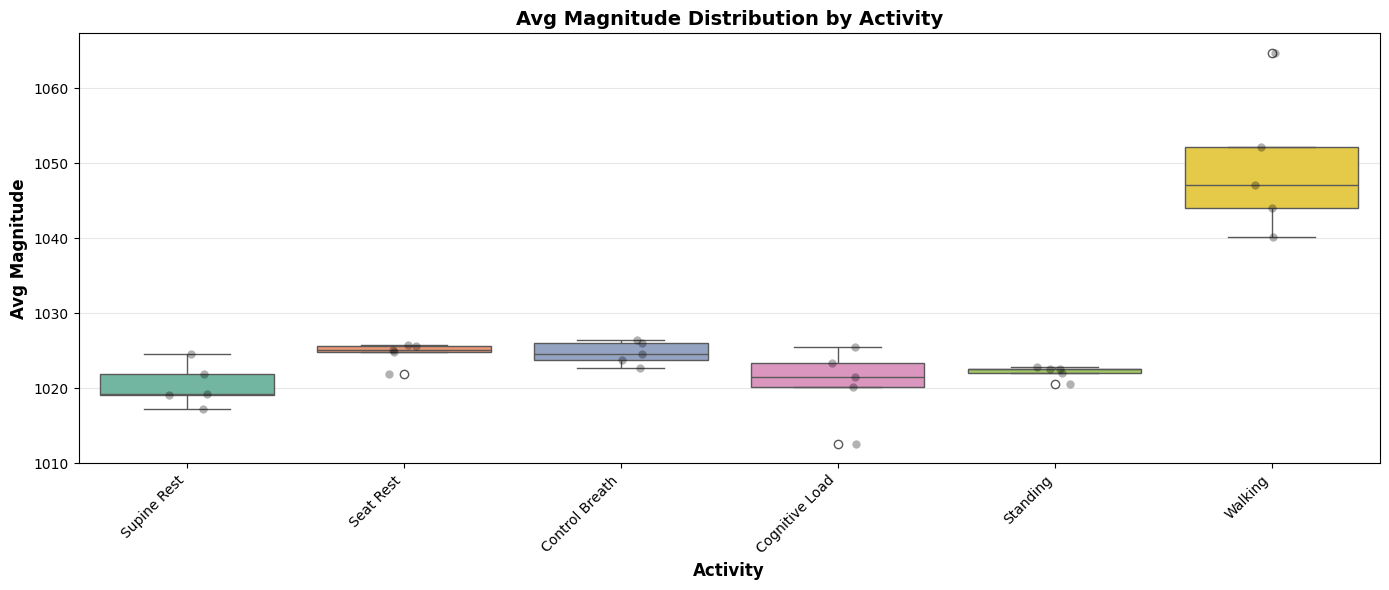

In [172]:
print("Generating Average Magnitude Boxplot...")
plot_activity_boxplots_from_metrics(df_metrics, 'avg_magnitude')


Generating Standard Deviation (Shakiness) Boxplot...


C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x='activity', y=metric_col, ax=ax, palette='Set2')
C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


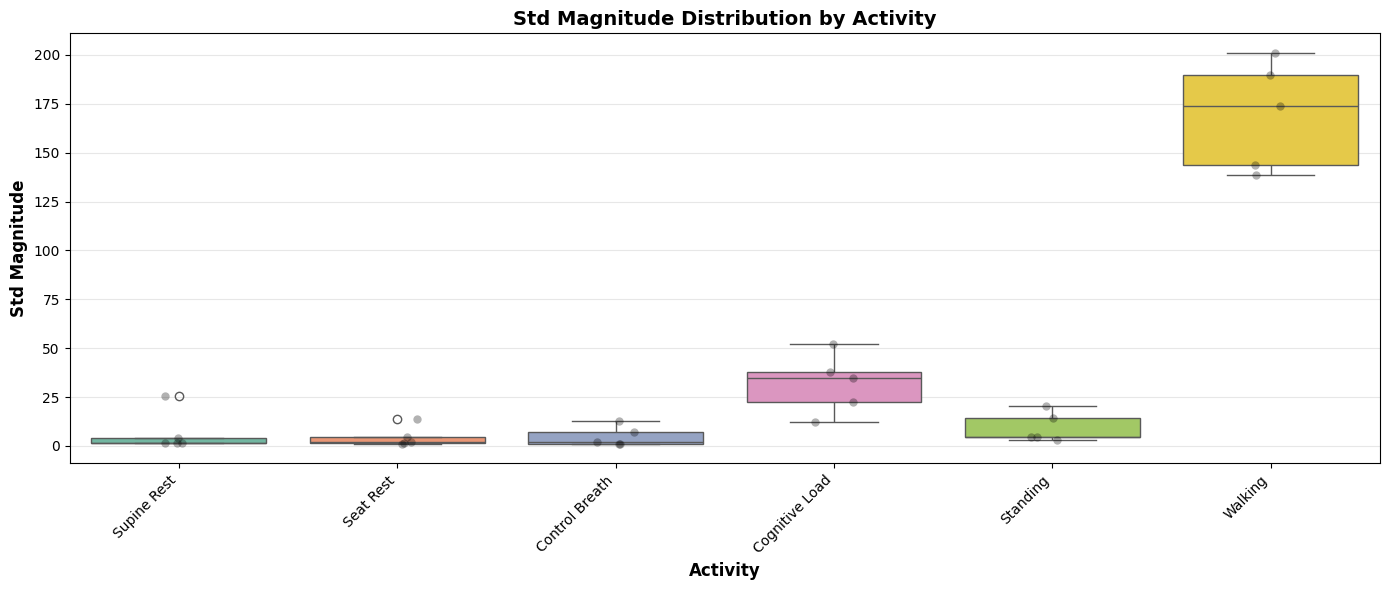

In [173]:
print("Generating Standard Deviation (Shakiness) Boxplot...")
plot_activity_boxplots_from_metrics(df_metrics, 'std_magnitude')


Generating Range Magnitude Boxplot...


C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x='activity', y=metric_col, ax=ax, palette='Set2')
C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


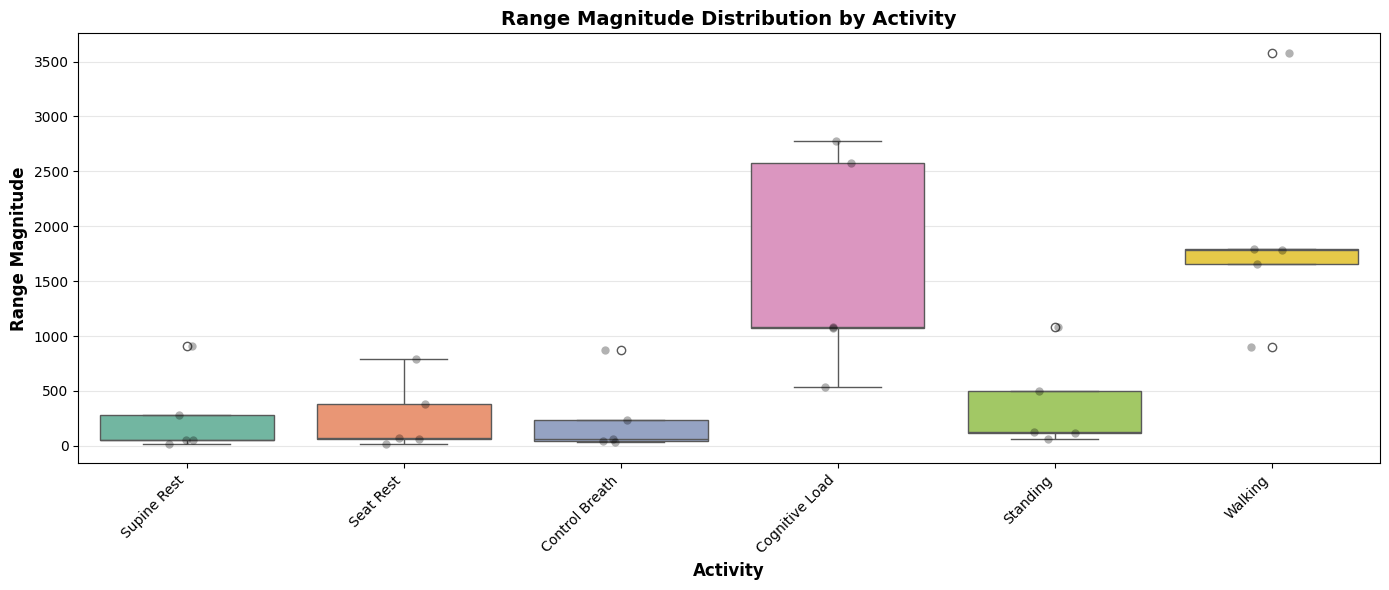

In [174]:
print("Generating Range Magnitude Boxplot...")
plot_activity_boxplots_from_metrics(df_metrics, 'range_magnitude')


C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metrics, x='activity', y=metric_col, ax=ax, palette='Set2')
C:\Users\seghi\AppData\Local\Temp\ipykernel_25320\2137190674.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Generating Mean Jerk Magnitude Boxplot...


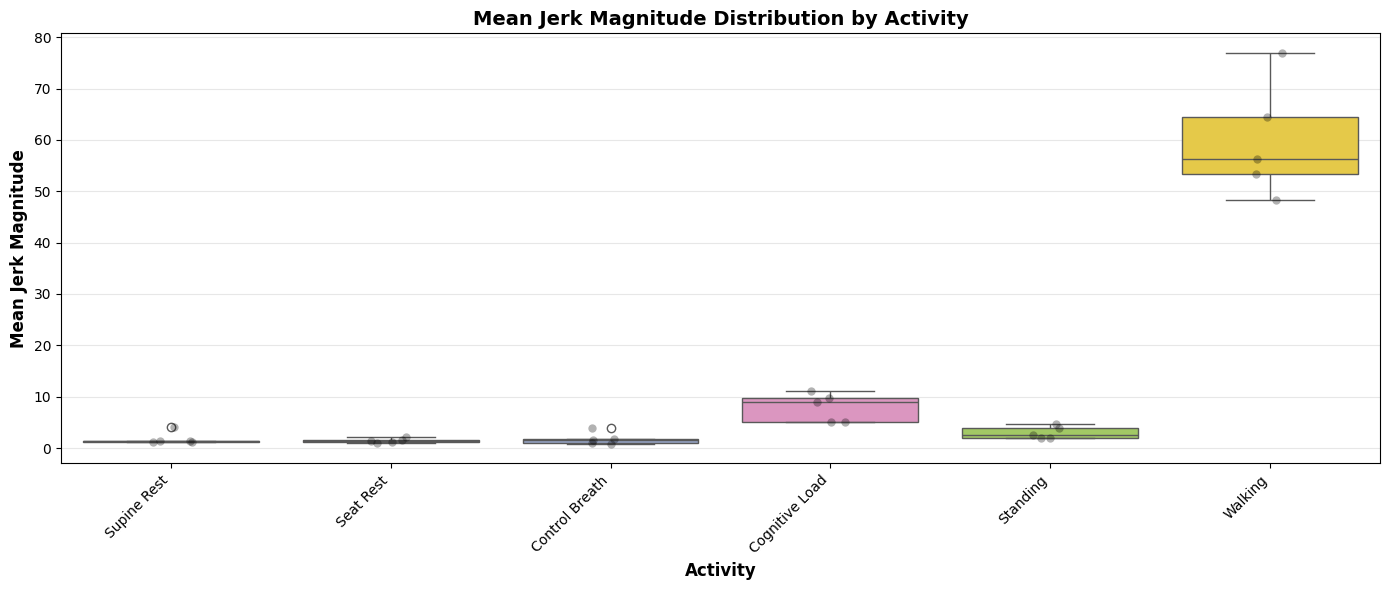

In [175]:
print("Generating Mean Jerk Magnitude Boxplot...")
plot_activity_boxplots_from_metrics(df_metrics, 'mean_jerk_magnitude')


In [176]:
# Print activity thresholds based on avg_magnitude
print("\n" + "="*70)
print("RECOMMENDED ACC MAGNITUDE THRESHOLDS FOR ACTIVITY CLASSIFICATION")
print("="*70 + "\n")

for activity in ACTIVITIES:
    activity_data = df_metrics[df_metrics['activity'] == activity]
    avg_mag = activity_data['avg_magnitude'].values

    if len(avg_mag) > 0:
        mean_val = np.mean(avg_mag)
        std_val = np.std(avg_mag)
        min_val = np.min(avg_mag)
        max_val = np.max(avg_mag)

        print(f"{activity.upper()}")
        print(f"  Range:        {min_val:.3f}g - {max_val:.3f}g")
        print(f"  Mean ± Std:   {mean_val:.3f}g ± {std_val:.3f}g")
        print(f"  Suggested threshold: < {mean_val + 0.5*std_val:.3f}g")
        print()

print("="*70)



RECOMMENDED ACC MAGNITUDE THRESHOLDS FOR ACTIVITY CLASSIFICATION

SUPINE REST
  Range:        1017.195g - 1024.532g
  Mean ± Std:   1020.384g ± 2.558g
  Suggested threshold: < 1021.663g

SEAT REST
  Range:        1021.867g - 1025.743g
  Mean ± Std:   1024.657g ± 1.436g
  Suggested threshold: < 1025.375g

CONTROL BREATH
  Range:        1022.644g - 1026.389g
  Mean ± Std:   1024.687g ± 1.401g
  Suggested threshold: < 1025.388g

COGNITIVE LOAD
  Range:        1012.579g - 1025.485g
  Mean ± Std:   1020.631g ± 4.407g
  Suggested threshold: < 1022.834g

STANDING
  Range:        1020.565g - 1022.774g
  Mean ± Std:   1022.099g ± 0.806g
  Suggested threshold: < 1022.502g

WALKING
  Range:        1040.179g - 1064.738g
  Mean ± Std:   1049.658g ± 8.493g
  Suggested threshold: < 1053.904g

